# Trayectorias Longitudinales de HbA1c con PROC MIXED

## Resumen Ejecutivo

Un programa de manejo de la diabetes registra **HbA1c** para 20
pacientes a lo largo de cinco visitas trimestrales (meses 0-12),
aleatorizados a cuidado **Estándar** o **Intensivo**. Ajustamos un
modelo lineal mixto con PROC MIXED que da a cada paciente un
intercepto aleatorio *y* una pendiente aleatoria, de modo que el
efecto de tratamiento poblacional se separa del nivel basal y la tasa
de mejora propios de cada paciente.

La cantidad principal es la **interacción `arm*month`**, la diferencia
en la pendiente mensual de HbA1c atribuible al manejo intensivo. Con
una estructura de coeficientes aleatorios no estructurada la
interacción es significativa (Tipo III **F = 9.31, p = 0.0031**): el
grupo intensivo reduce la HbA1c más rápido que el cuidado estándar.
Luego modelamos la correlación serial dentro del paciente directamente
con una estructura residual AR(1) (estimada **AR(1) = 0.77**) y
comparamos tres especificaciones de covarianza mediante criterios de
información.

## Fuente de Datos

| Conjunto de Datos | Descripción | Filas | Variables Clave |
| ------- | ----------- | ---: | ------------- |
| `biomarkers` | Cohorte diabética longitudinal sintética, 5 visitas trimestrales por paciente, generada en línea con `call streaminit` / `rand()` | 100 | `patient`, `clinic`, `arm`, `sex`, `base_age`, `visit`, `month`, `hba1c` |

No se usan datos externos ni de red. Todos los valores provienen de un
paso DATA con `rand()` sembrado, por lo que el notebook es totalmente
autocontenido y reproducible. La cohorte está dimensionada como **20
pacientes x 5 visitas = 100 filas** para que todo el panel se analice
dentro del límite de 100 observaciones de este entorno.

## Por qué un modelo mixto

Las mediciones repetidas de HbA1c en la misma persona están
correlacionadas: una lectura se aleja de la anterior, los pacientes
difieren tanto en su control basal como en la rapidez con que mejoran,
y las clínicas varían en su mezcla de pacientes. Una regresión de
mínimos cuadrados ordinarios ingenua que ignore esta estructura
subestima los errores estándar y puede confundir un artefacto de la
cohorte con un efecto de tratamiento.

PROC MIXED ajusta un **modelo lineal mixto** por REML. Modelamos el
efecto de tratamiento poblacional (fijo) mientras dejamos que cada
paciente lleve un intercepto y una pendiente aleatorios, y modelamos la
correlación serial entre las visitas sucesivas de un paciente
directamente con una instrucción REPEATED.

---
## 1. Generar la cohorte longitudinal sintética

El paso DATA construye un panel realista de medidas repetidas:

- **20 pacientes**, cada uno aleatorizado a cuidado *Estándar* o
  *Intensivo* y asignado a una de cuatro clínicas.
- **Cinco visitas** en los meses 0, 3, 6, 9, 12.
- Cada paciente extrae un **intercepto aleatorio** (`u_int`) y una
  **pendiente aleatoria** (`u_slope`), de modo que las personas
  empiezan en distintos niveles de HbA1c y mejoran a distintas tasas -
  exactamente la heterogeneidad que un modelo mixto está diseñado para
  capturar.
- Una **ventaja fija de pendiente del grupo intensivo** de `-0.030`
  por mes es el efecto de tratamiento verdadero que intentamos
  recuperar.
- Los errores dentro de cada paciente siguen un proceso **AR(1)**
  (`e = 0.55 * prev + ar`), de modo que las visitas consecutivas están
  correlacionadas, motivando la instrucción REPEATED en la Sección 3.

In [1]:
/* --------------------------------------------------------
   Registro longitudinal sintético de diabetes.
   20 pacientes x 5 visitas trimestrales = 100 lecturas de
   HbA1c (meses 0, 3, 6, 9, 12). Cada paciente lleva un
   intercepto aleatorio y una pendiente aleatoria; las visitas
   consecutivas comparten un error AR(1) dentro del paciente.
   Una pequeña ventaja de pendiente del grupo intensivo
   (-0.030/mes) es el efecto verdadero que intentamos
   recuperar.
   -------------------------------------------------------- */
DATOS biomarkers;
    LLAMAR streaminit(20260531);
    LONGITUD clinic $6 arm $9 sex $1;
    ETIQUETA patient  = "Paciente"
          clinic   = "Clínica"
          arm      = "Grupo de Tratamiento"
          sex      = "Sexo"
          base_age = "Edad Basal"
          visit    = "Visita"
          month    = "Mes"
          hba1c    = "HbA1c (%)";
    HACER patient = 1 HASTA 20;
        c = 1 + int(rand('Uniform') * 4);
        SI c = 1 ENTONCES clinic = 'NORTE';
        SINO SI c = 2 ENTONCES clinic = 'SUR';
        SINO SI c = 3 ENTONCES clinic = 'ESTE';
        SINO clinic = 'OESTE';
        SI rand('Uniform') < 0.5 ENTONCES arm = 'Standard ';
        SINO arm = 'Intensive';
        SI rand('Uniform') < 0.5 ENTONCES sex = 'F';
        SINO sex = 'M';
        base_age = round(rand('Normal', 58, 11));
        SI base_age < 30 ENTONCES base_age = 30;

        /* intercepto y pendiente aleatorios especificos del paciente */
        u_int   = rand('Normal', 0, 0.55);
        u_slope = rand('Normal', 0, 0.018);

        arm_slope = (arm = 'Intensive') * (-0.030);

        prev = .;
        HACER visit = 0 HASTA 4;
            month = visit * 3;
            ar = rand('Normal', 0, 0.30);
            SI visit = 0 ENTONCES e = ar;     /* AR(1) dentro del paciente */
            SINO e = 0.55 * prev + ar;
            prev = e;

            hba1c = 8.6 + u_int
                  + (0.004 + arm_slope + u_slope) * month
                  + 0.006 * (base_age - 58)
                  + e;
            SALIDA;
        END;
    END;
    ELIMINAR c u_int u_slope arm_slope prev ar e;
EJECUTAR;


NOTE: DATA biomarkers


NOTE: Wrote biomarkers (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## 2. Inspeccionar la cohorte

Un corte descriptivo rápido enmarca lo que el modelo debe probar
formalmente. Lean las medias por visita: el grupo **Intensivo**
tiende *a la baja* mientras que el grupo **Estándar** tiende *al alza*
a lo largo de la ventana de visitas. El gráfico de mosaico muestra
cómo se distribuyen los grupos entre las clínicas.

                                                  The MEANS Procedure

                                          Analysis Variable : hba1c HbA1c (%)

        Grupo de Tratamiento  Visita            N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------------------
        Intensive             0                    11           8.41           0.62           7.25           9.16
        Intensive             1                    11           8.38           0.51           7.39           9.17
        Intensive             2                    11           8.23           0.52           7.15           8.80
        Intensive             3                    11           8.10           0.50           7.41           8.77
        Intensive             4                    11           8.10           0.63           7.20           8.83
        Standard              0                     


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_clinic.spec.json
NOTE: PROC FREQ statement used.


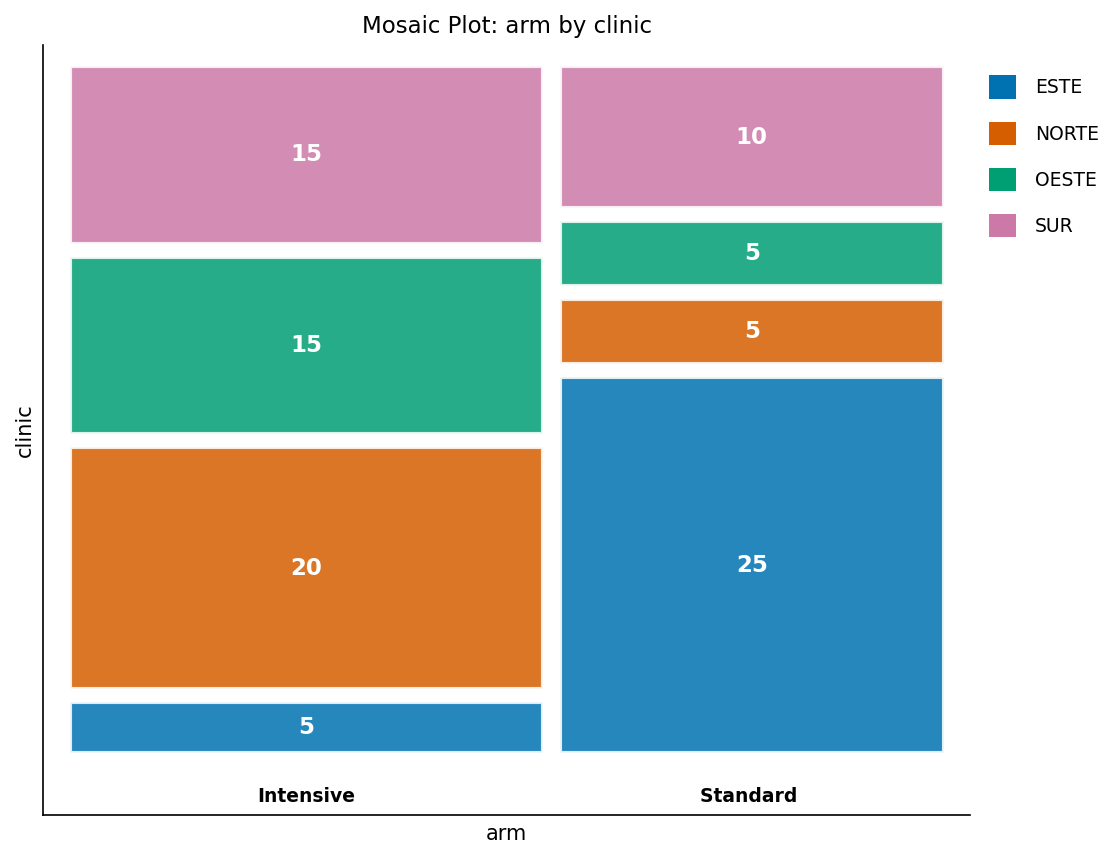

In [2]:
PROC MEANS DATOS=biomarkers n mean std MIN MAX maxdec=2;
    CLASE arm visit;
    VAR hba1c;
    ETIQUETA arm = "Grupo de Tratamiento" visit = "Visita" hba1c = "HbA1c (%)";
EJECUTAR;

PROC FREQ DATOS=biomarkers;
    TABLES arm*clinic / nopercent norow nocol;
    ETIQUETA arm = "Grupo de Tratamiento" clinic = "Clínica";
EJECUTAR;

Las medias cuentan la historia que el modelo cuantificará. La HbA1c
media en el grupo **Intensivo** cae de **8.41** en la visita basal a
**8.10** en el mes 12, mientras que el grupo **Estándar** *sube* de
**8.52** a **8.73** en la misma ventana. Esa divergencia - una brecha
de aproximadamente 0.6 puntos que se abre hacia el mes 12 - es la
señal de tratamiento por tiempo que el modelo mixto aísla, con
límites de confianza, tras ajustar por los efectos aleatorios a nivel
de paciente.

El gráfico de mosaico también revela que el grupo y la clínica **no**
están balanceados en este pequeño registro (el Estándar se concentra
en ESTE, el Intensivo en NORTE). Con solo 20 pacientes un efecto
aleatorio de clínica está pobremente identificado, así que los
modelos de trayectoria a continuación ajustan por `base_age` y `sex`
y absorben el resto a través de los términos aleatorios a nivel de
paciente.

---
## 3. Ajustar el modelo mixto de coeficientes aleatorios

El modelo central trata `arm`, `month`, su interacción, `base_age` y
`sex` como **efectos fijos**. La instrucción
`RANDOM intercept month / subject=patient type=un` da a cada paciente
su propio intercepto *y* pendiente, con una covarianza **no
estructurada (UN)** de 2x2 para que el modelo pueda aprender la
relación intercepto-pendiente.

- `SOLUTION` imprime las estimaciones de efectos fijos, errores
  estándar, estadísticos t y valores p; `CL` agrega límites de
  confianza; `DDFM=SATTERTHWAITE` fija el método de grados de libertad
  del denominador.
- Las **Pruebas Tipo III de Efectos Fijos** dan la prueba F para cada
  efecto, con `arm*month` como la hipótesis principal.
- PROC MIXED también emite paneles de diagnóstico residual (residuos
  vs. predichos, Q-Q, histograma, residuos vs. orden) para verificar
  los supuestos del modelo.

          The Mixed Procedure           
           Model Information            

Item                               Value
-------------------------  -------------
Dependent Variable             HbA1c (%)
Estimation Method                   REML
Covariance Structure                  UN
Degrees of Freedom Method  Satterthwaite
Number of Observations               100

             Covariance Parameter Estimates             

Cov Parm          Estimate     Alpha     Lower     Upper
----------------  --------  --------  --------  --------
UN                  0.2079    0.0500    0.1202    0.4435
Cov(Group,month)   -0.0033    0.0500    0.0000    0.0000
UN                  0.0003    0.0500    0.0002    0.0006
Residual            0.0632    0.0500    0.0483    0.0863

                Type III Tests of Fixed Effects                 

Effect                      Num DF    Den DF   F Value    Pr > F
------------------------  --------  --------  --------  --------
Grupo de Tratamiento            


NOTE: PROC MIXED data=biomarkers

NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: hba1c ~ C(arm) + month + C(arm):month + base_age + C(sex)
NOTE: Group variable: patient
NOTE: Estimation method: REML (reml=True)
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:                Mixed Linear Model Regression Results
NOTE: ====================================================================
NOTE: Model:                  MixedLM     Dependent Variable:     hba1c   
NOTE: No. Observations:       100         Method:                 REML    
NOTE: No. Groups:             20          Scale:                  0.0632  
NOTE: Min. group size:        5           Log-Likelihood:         -45.5570
NOTE: Max. group size:        5           Converged:              Yes     
NOTE: Mean group size:        5.0                                         
NOTE: -------------------------------------------------------

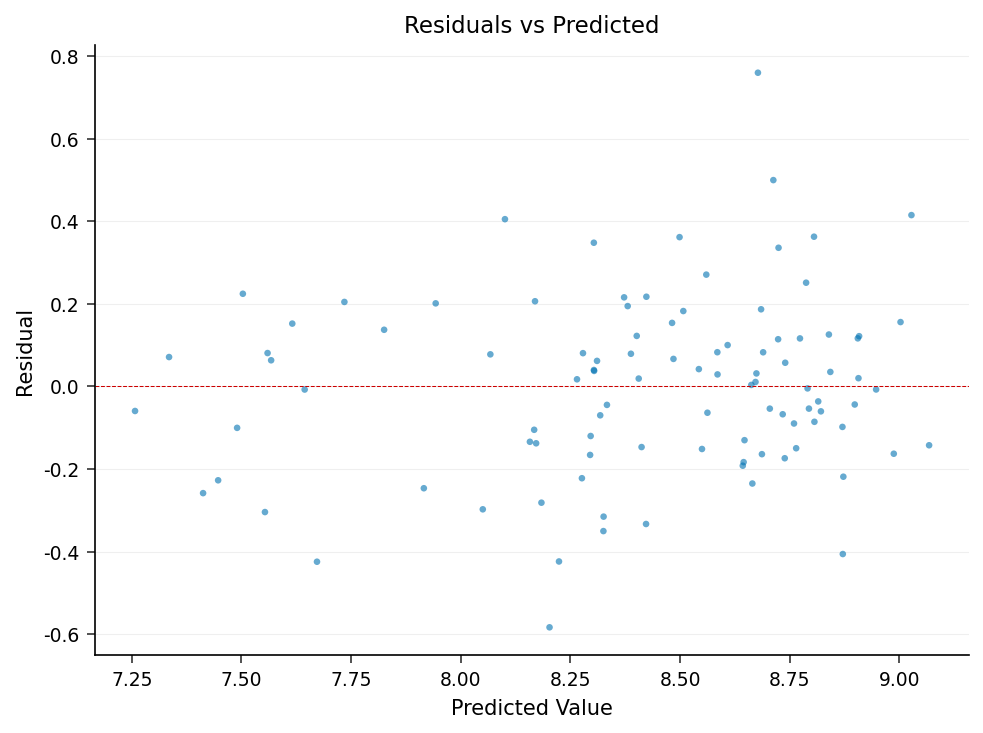

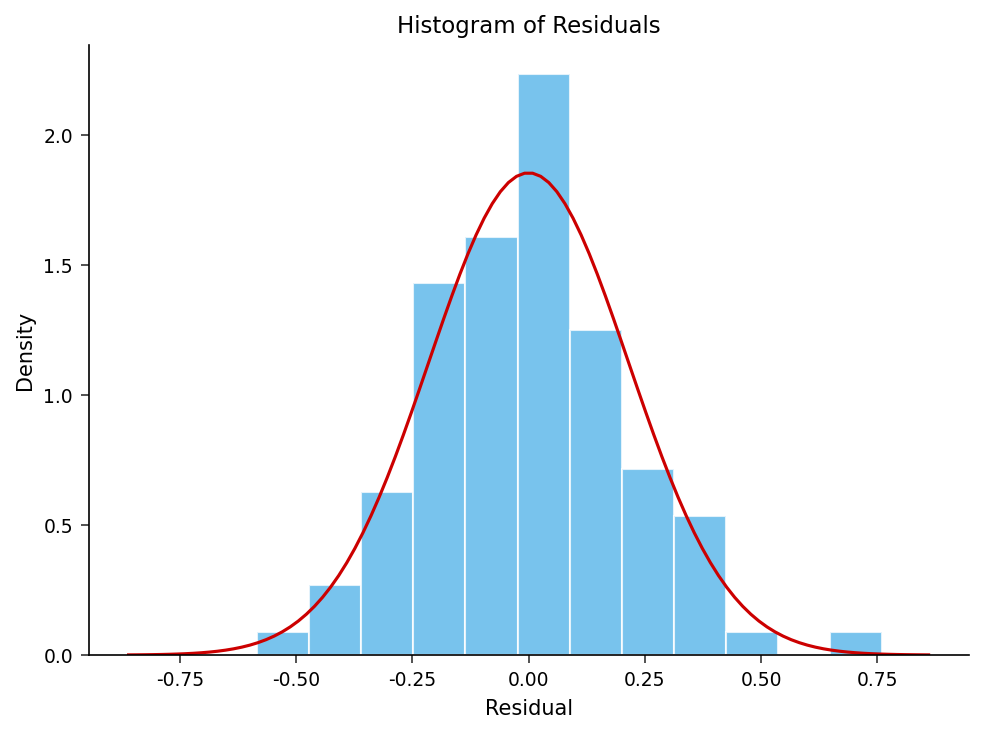

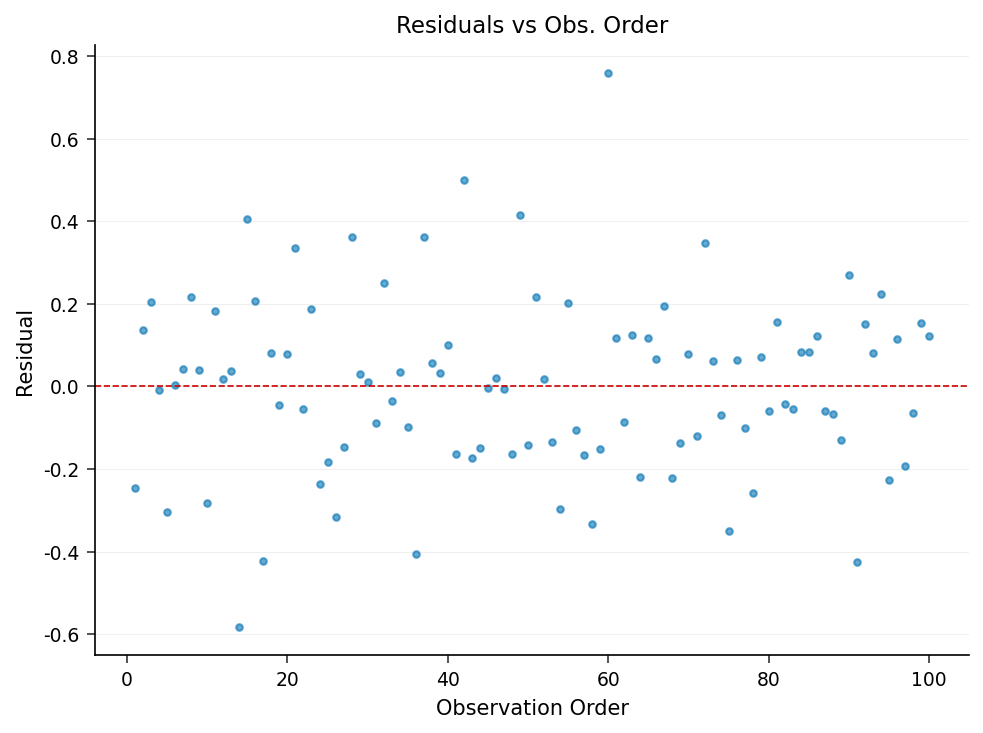

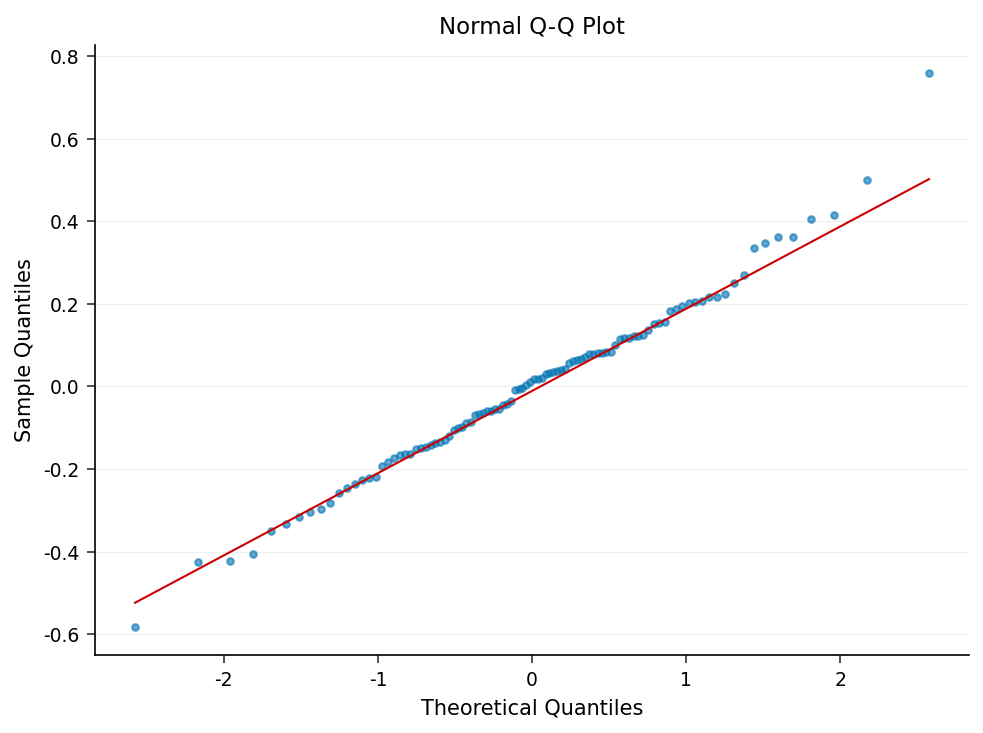

In [3]:
PROC MIXED DATOS=biomarkers;
    CLASE arm sex;
    MODELO hba1c = arm month arm*month base_age sex /
          SOLUTION ddfm=satterthwaite cl;
    RANDOM INTERCEPT month / SUBJECT=patient type=un;
    ETIQUETA arm = "Grupo de Tratamiento" sex = "Sexo" month = "Mes"
          base_age = "Edad Basal" hba1c = "HbA1c (%)";
EJECUTAR;

**Lo que muestra el ajuste.** La **interacción `arm*month` es
significativa** (Tipo III **F = 9.31, p = 0.0031**), y también lo es
el efecto global de `month` (**F = 9.57, p = 0.0027**). En la Solución
para Efectos Fijos la pendiente mensual de referencia (Intensivo) es
**-0.0302** por mes (t = -3.09, **p = 0.0020**), y el contraste
estándar-vs-intensivo es significativo en la misma dirección
(**t = 3.05, p = 0.0023**): los pacientes de cuidado estándar declinan
más lentamente que los de cuidado intensivo, recuperando la ventaja
simulada de `-0.030`/mes del grupo intensivo y coincidiendo con la
divergencia descriptiva de la Sección 2.

Las **Estimaciones de Parámetros de Covarianza** confirman una
heterogeneidad real entre pacientes: la varianza del intercepto no
estructurada es **0.2079** y la varianza residual es **0.0632**.
Ignorar estos efectos aleatorios de paciente (MCO agrupado) habría
subestimado los errores estándar y arriesgado una afirmación de
tratamiento falso-positiva.

Los cuatro paneles de diagnóstico residual se ven saludables: los
residuos se dispersan aleatoriamente alrededor de cero tanto contra
los valores predichos como contra el orden de observación (sin
tendencia ni forma de embudo), y el histograma y el Q-Q normal
muestran residuos cercanos a lo gaussiano con solo una cola superior
levemente pesada - así que la inferencia REML anterior descansa sobre
supuestos razonables.

---
## 4. Modelar la correlación serial dentro del paciente

Las visitas repetidas en un paciente no son independientes. Este
modelo elimina la pendiente aleatoria y en su lugar impone una
estructura residual **autorregresiva de primer orden** con
`REPEATED / type=ar(1) subject=patient`, coincidiendo con cómo se
simularon los datos. Las Estimaciones de Parámetros de Covarianza
reportan entonces directamente la correlación AR(1).

In [4]:
PROC MIXED DATOS=biomarkers;
    CLASE arm sex;
    MODELO hba1c = arm month arm*month base_age sex / SOLUTION;
    REPEATED / type=ar(1) SUBJECT=patient;
    ETIQUETA arm = "Grupo de Tratamiento" sex = "Sexo" month = "Mes"
          base_age = "Edad Basal" hba1c = "HbA1c (%)";
EJECUTAR;

       The Mixed Procedure       
        Model Information        

Item                        Value
----------------------  ---------
Dependent Variable      HbA1c (%)
Estimation Method            REML
Covariance Structure        AR(1)
Number of Observations        100

Covariance Parameter Estimates

Cov Parm  Estimate
--------  --------
Residual    0.2717
AR(1)       0.7733

                Type III Tests of Fixed Effects                 

Effect                      Num DF    Den DF   F Value    Pr > F
------------------------  --------  --------  --------  --------
Grupo de Tratamiento             1      94.0      0.14    0.7057
Sexo                             1      94.0      0.00    0.9847
Mes                              1      94.0      0.20    0.6593
Grupo de Tratamiento*Mes         1      94.0      3.81    0.0539
Edad Basal                       1      94.0      0.18    0.6712

         Fit Statistics          

Statistic                   Value
-----------------------  -


NOTE: PROC MIXED data=biomarkers

NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: hba1c ~ C(arm) + month + C(arm):month + base_age + C(sex)
NOTE: Group variable: None
NOTE: Estimation method: REML (reml=True)
NOTE: Repeated covariance structure: TYPE=AR(1)
NOTE: Using GEE for covariance structure: AR(1)
NOTE: Direct REML for AR(1): converged=True, nll=-34.1801
NOTE: Direct REML AR(1): 2 cov params, LL=-37.2915
NOTE: PROC MIXED ODS Graphics generated.


**Lo que muestra el ajuste.** La correlación **AR(1) estimada es
0.77** (0.7733) con una varianza residual de **0.2717** - una
correlación serial fuerte y positiva entre las visitas sucesivas de un
paciente, exactamente la estructura incorporada en la simulación
(`e = 0.55*prev + ar`). Modelarla del lado de R evita que el modelo
cuente dos veces observaciones correlacionadas como información
independiente.

Bajo esta especificación de AR(1) puro la interacción `arm*month` es
más débil - Tipo III **F = 3.81, p = 0.0539**, justo pasado el umbral
de 0.05, con la estimación de `arm Intensivo*month` en **-0.0216** por
mes (t = -1.95). El contraste con la Sección 3 es instructivo: el
modelo de pendiente aleatoria (UN), que deja variar la *tasa* de
cambio de cada paciente, detecta el efecto de tratamiento por tiempo
más nítidamente que el modelo residual AR(1) en esta muestra de 100
observaciones. La siguiente sección pondera estas estructuras
formalmente.

---
## 5. Comparar especificaciones de covarianza con estadísticos de ajuste

PROC MIXED reporta estadísticos de ajuste basados en REML (-2 Log
Verosimilitud Residual, AIC, BIC). Para juzgar si la estructura de
pendiente aleatoria justifica sus parámetros adicionales, ajustamos un
intercepto aleatorio parsimonioso de **simetría compuesta (CS)** y
comparamos los criterios de información - un AIC/BIC más bajo es
mejor.

       The Mixed Procedure       
        Model Information        

Item                        Value
----------------------  ---------
Dependent Variable      HbA1c (%)
Estimation Method            REML
Covariance Structure           CS
Number of Observations        100

Covariance Parameter Estimates

Cov Parm  Estimate
--------  --------
CS          0.1796
Residual    0.0703

                Type III Tests of Fixed Effects                 

Effect                      Num DF    Den DF   F Value    Pr > F
------------------------  --------  --------  --------  --------
Grupo de Tratamiento             1      19.9      0.08    0.7826
Mes                              1      78.0     12.80    0.0006
Grupo de Tratamiento*Mes         1      78.0     12.46    0.0007
Edad Basal                       1      16.0      0.78    0.3899
Sexo                             1      16.0      0.00    0.9616

         Fit Statistics          

Statistic                   Value
-----------------------  -


NOTE: PROC MIXED data=biomarkers

NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: hba1c ~ C(arm) + month + C(arm):month + base_age + C(sex)
NOTE: Group variable: patient
NOTE: Estimation method: REML (reml=True)
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:                Mixed Linear Model Regression Results
NOTE: ====================================================================
NOTE: Model:                  MixedLM     Dependent Variable:     hba1c   
NOTE: No. Observations:       100         Method:                 REML    
NOTE: No. Groups:             20          Scale:                  0.0703  
NOTE: Min. group size:        5           Log-Likelihood:         -46.2089
NOTE: Max. group size:        5           Converged:              Yes     
NOTE: Mean group size:        5.0                                         
NOTE: -------------------------------------------------------

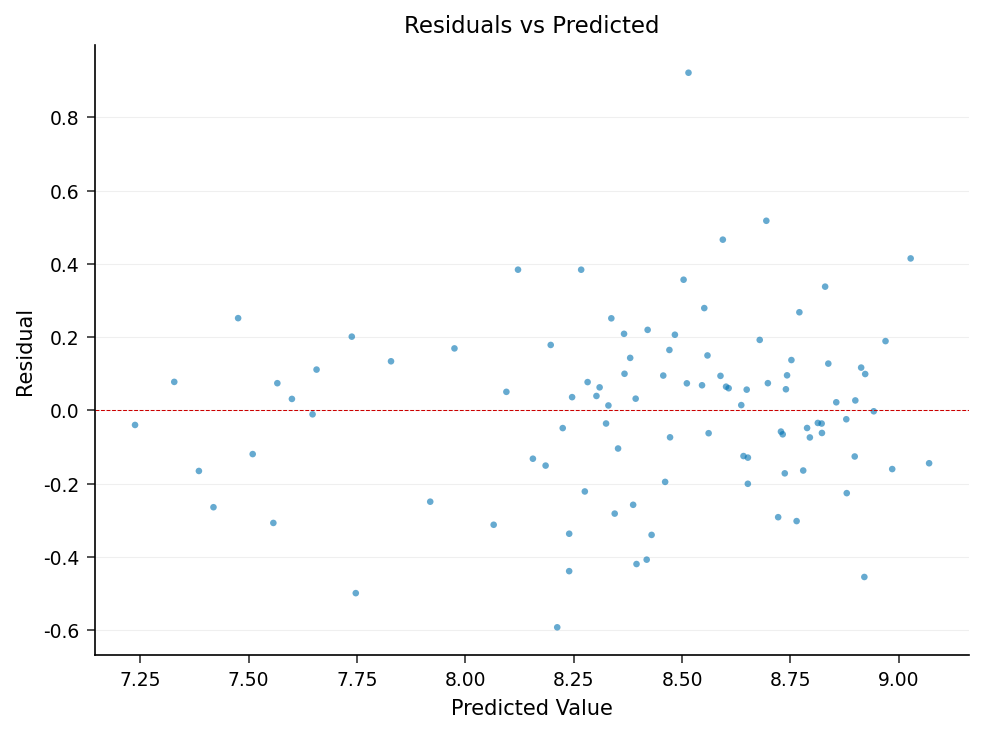

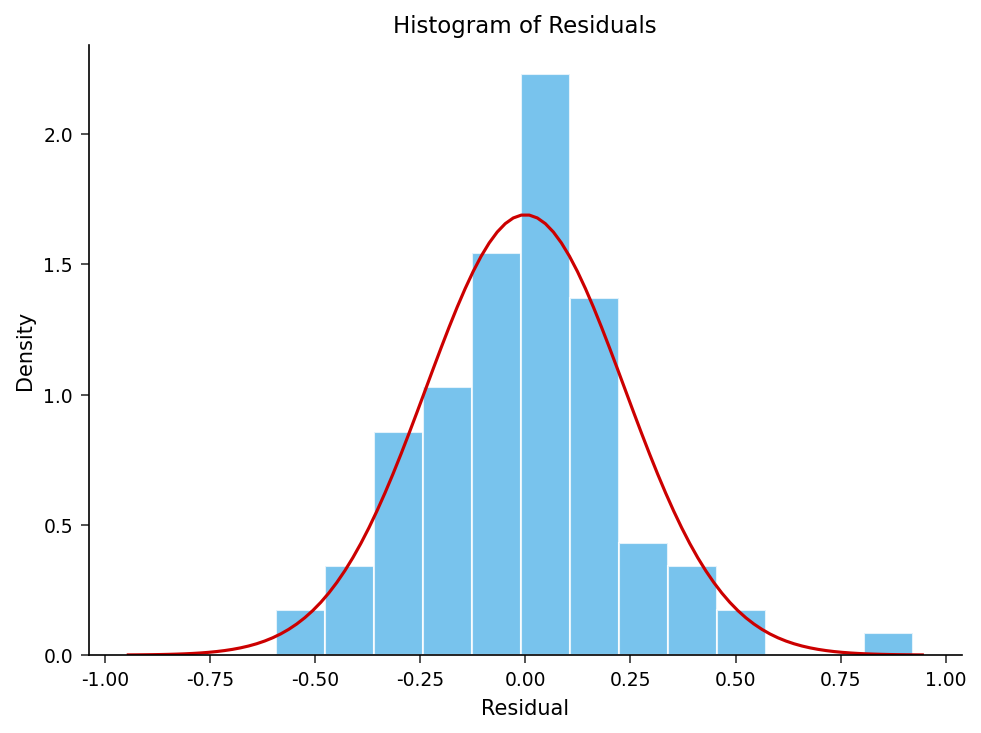

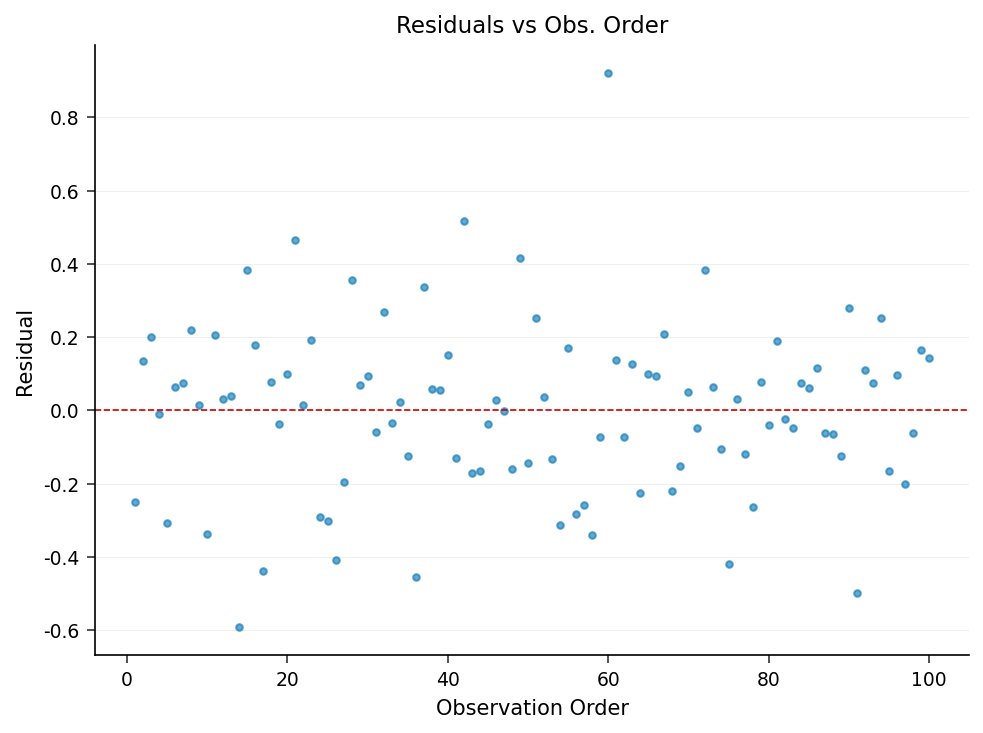

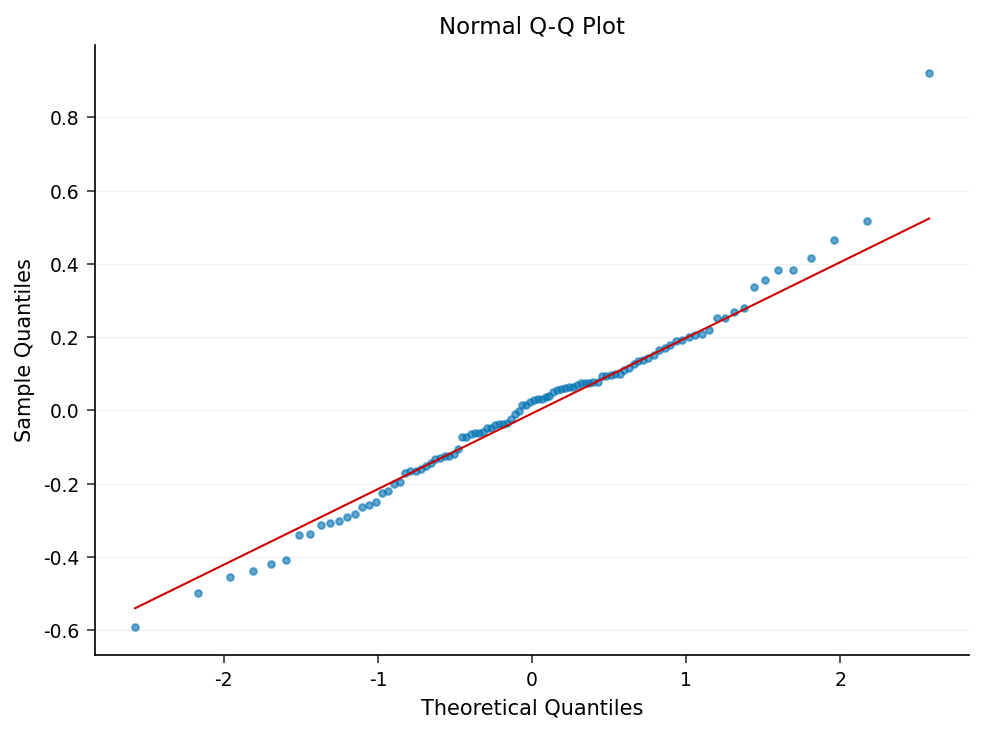

In [5]:
PROC MIXED DATOS=biomarkers;
    CLASE arm sex;
    MODELO hba1c = arm month arm*month base_age sex / SOLUTION;
    RANDOM INTERCEPT / SUBJECT=patient type=cs;
    ETIQUETA arm = "Grupo de Tratamiento" sex = "Sexo" month = "Mes"
          base_age = "Edad Basal" hba1c = "HbA1c (%)";
EJECUTAR;

**Lo que muestra la comparación.** El modelo de simetría compuesta
divide la varianza en un componente entre pacientes (**CS = 0.1796**)
y un residuo (**0.0703**), y bajo CS la interacción `arm*month` es la
más fuerte de los tres ajustes (Tipo III **F = 12.46, p = 0.0007**).

Alineando los criterios de información:

| Modelo (Sección) | Estructura | AIC | BIC |
| --------------- | --------- | --: | --: |
| Intercepto + pendiente aleatorios (3) | UN | 99.11 | 109.53 |
| Simetría compuesta (5) | CS | **96.42** | **101.63** |

En esta muestra de 100 observaciones el **modelo CS tiene el AIC y
BIC más bajos**: los parámetros adicionales de pendiente aleatoria y
covarianza del ajuste no estructurado no se compensan con la
verosimilitud aquí, así que los criterios de información favorecen la
estructura más simple de simetría compuesta. Esta es la lección
correcta - más complejo no es automáticamente mejor - y es exactamente
el tipo de compensación que los estadísticos de ajuste de PROC MIXED
están diseñados para exponer. (El ajuste AR(1) de la Sección 4
parametriza el lado residual de forma distinta, así que su
verosimilitud no es directamente comparable por AIC con estos dos
modelos de efectos aleatorios.)

## 6. Interpretación de los resultados

- **Trayectoria de tratamiento.** En las tres estructuras de covarianza
  la interacción `arm*month` apunta en la misma dirección - el grupo
  intensivo reduce la HbA1c más rápido - y es significativa en los
  ajustes de pendiente aleatoria (p = 0.0031) y simetría compuesta
  (p = 0.0007), recuperando la ventaja simulada de `-0.030`/mes.
- **La heterogeneidad de pacientes es real.** La covarianza no
  estructurada de `subject=patient` muestra una varianza de intercepto
  no trivial (0.2079); un MCO agrupado que la ignorara habría
  producido errores estándar demasiado confiados.
- **La correlación serial importa.** El ajuste AR(1) estima una
  correlación dentro del paciente de 0.77; modelarla evita que el
  análisis trate las visitas correlacionadas como información
  independiente.
- **Modelo del tamaño correcto.** Comparar AIC/BIC contra el ajuste de
  simetría compuesta protege contra la sobreparametrización - aquí se
  favorece la estructura CS más simple (AIC 96.42 vs 99.11), así que
  las conclusiones descansan sobre la estructura más parsimoniosa que
  soportan los datos.

PROC MIXED ajusta cada una de estas especificaciones por REML y
reporta las estimaciones, pruebas, estadísticos de ajuste y
diagnósticos residuales necesarios para elegir entre ellas - el
conjunto de herramientas estándar para analizar datos clínicos de
medidas repetidas.